In [1]:
!pip install yfinance pandas numpy matplotlib seaborn scipy requests fpdf2 plotly --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 9.7 MB/s eta 0:00:00


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import yfinance as yf
from scipy import stats
from datetime import datetime

warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0A1628'
plt.rcParams['axes.facecolor']   = '#0A1628'
plt.rcParams['axes.edgecolor']   = '#1E3A5F'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['grid.color']       = '#1E3A5F'
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.family']      = 'monospace'

# ── PASTE YOUR FREE FMP API KEY HERE ──────────────────────────────────────────
FMP_API_KEY = "yJdXxLlW5At3kncO6n7pWwpWSyDNZEXa"

RBA_10Y_YIELD    = 0.0435   # RBA 10-year bond yield (risk-free rate for WACC)
EQUITY_RISK_PREM = 0.065    # Australian equity risk premium (approx 6.5%)
TERMINAL_GROWTH  = 0.025    # Long-run terminal growth rate (approx RBA inflation target)

GOLD  = '#C8972B'
BLUE  = '#4A90D9'
GREEN = '#2ECC71'
RED   = '#E74C3C'
WHITE = '#FFFFFF'
GREY  = '#8899AA'

# ASX 200 stocks to screen - broad cross-sector selection
ASX_STOCKS = [
    "CBA.AX", "NAB.AX", "WBC.AX", "ANZ.AX", "MQG.AX",
    "BHP.AX", "RIO.AX", "FMG.AX", "S32.AX", "MIN.AX",
    "CSL.AX", "RMD.AX", "COH.AX", "SHL.AX",
    "WES.AX", "WOW.AX", "COL.AX", "JBH.AX",
    "XRO.AX", "WTC.AX", "CPU.AX",
    "GMG.AX", "SCG.AX", "GPT.AX",
    "WDS.AX", "STO.AX",
    "TCL.AX", "APA.AX", "AGL.AX"
]

# FMP uses different ticker format - remove .AX and add exchange
def to_fmp_ticker(asx_ticker):
    return asx_ticker.replace('.AX', '') + '.AX'

print("=" * 60)
print("  ASX FUNDAMENTAL SCREENER & DCF VALUATION")
print("=" * 60)
print(f"  Universe      : {len(ASX_STOCKS)} ASX stocks")
print(f"  Risk-free rate: {RBA_10Y_YIELD*100:.2f}% (RBA 10Y)")
print(f"  ERP           : {EQUITY_RISK_PREM*100:.1f}%")
print(f"  Terminal growth: {TERMINAL_GROWTH*100:.1f}%")
print("=" * 60)

  ASX FUNDAMENTAL SCREENER & DCF VALUATION
  Universe      : 29 ASX stocks
  Risk-free rate: 4.35% (RBA 10Y)
  ERP           : 6.5%
  Terminal growth: 2.5%


In [3]:
print("\nFetching financial data from Financial Modeling Prep...")
print("This may take 2-3 minutes...\n")

def get_fmp_data(ticker, endpoint, api_key, limit=5):
    base = "https://financialmodelingprep.com/api/v3"
    url  = f"{base}/{endpoint}/{ticker}?limit={limit}&apikey={api_key}"
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            return r.json()
        return []
    except Exception:
        return []

def get_key_metrics(ticker, api_key):
    return get_fmp_data(ticker, "key-metrics", api_key, limit=1)

def get_income_stmt(ticker, api_key):
    return get_fmp_data(ticker, "income-statement", api_key, limit=5)

def get_balance_sheet(ticker, api_key):
    return get_fmp_data(ticker, "balance-sheet-statement", api_key, limit=1)

def get_cash_flow(ticker, api_key):
    return get_fmp_data(ticker, "cash-flow-statement", api_key, limit=5)

def get_profile(ticker, api_key):
    return get_fmp_data(ticker, "profile", api_key, limit=1)

# Collect data for all stocks
all_data = {}
failed   = []

for i, ticker in enumerate(ASX_STOCKS):
    fmp_ticker = to_fmp_ticker(ticker)
    print(f"  [{i+1:02d}/{len(ASX_STOCKS)}] Fetching {fmp_ticker}...", end=' ')

    try:
        metrics  = get_key_metrics(fmp_ticker, FMP_API_KEY)
        income   = get_income_stmt(fmp_ticker, FMP_API_KEY)
        balance  = get_balance_sheet(fmp_ticker, FMP_API_KEY)
        cashflow = get_cash_flow(fmp_ticker, FMP_API_KEY)
        profile  = get_profile(fmp_ticker, FMP_API_KEY)

        if metrics and income and len(income) >= 1:
            all_data[ticker] = {
                'metrics' : metrics[0] if metrics else {},
                'income'  : income,
                'balance' : balance[0] if balance else {},
                'cashflow': cashflow,
                'profile' : profile[0] if profile else {}
            }
            print("OK")
        else:
            failed.append(ticker)
            print("No data")
    except Exception as e:
        failed.append(ticker)
        print(f"Error: {e}")

print(f"\nData fetched for {len(all_data)} stocks")
print(f"Failed: {len(failed)} stocks: {failed}")


Fetching financial data from Financial Modeling Prep...
This may take 2-3 minutes...

  [01/29] Fetching CBA.AX... No data
  [02/29] Fetching NAB.AX... No data
  [03/29] Fetching WBC.AX... No data
  [04/29] Fetching ANZ.AX... No data
  [05/29] Fetching MQG.AX... No data
  [06/29] Fetching BHP.AX... No data
  [07/29] Fetching RIO.AX... No data
  [08/29] Fetching FMG.AX... No data
  [09/29] Fetching S32.AX... No data
  [10/29] Fetching MIN.AX... No data
  [11/29] Fetching CSL.AX... No data
  [12/29] Fetching RMD.AX... No data
  [13/29] Fetching COH.AX... No data
  [14/29] Fetching SHL.AX... No data
  [15/29] Fetching WES.AX... No data
  [16/29] Fetching WOW.AX... No data
  [17/29] Fetching COL.AX... No data
  [18/29] Fetching JBH.AX... No data
  [19/29] Fetching XRO.AX... No data
  [20/29] Fetching WTC.AX... No data
  [21/29] Fetching CPU.AX... No data
  [22/29] Fetching GMG.AX... No data
  [23/29] Fetching SCG.AX... No data
  [24/29] Fetching GPT.AX... No data
  [25/29] Fetching WDS.AX

In [6]:
print("\nComputing fundamental ratios...")
print(f"Stocks with data: {len(all_data)}")

# Demo data for all 15 stocks
fundamentals = [
    {'Ticker': 'CBA.AX', 'Company': 'Commonwealth Bank', 'Sector': 'Financials', 'Price': 125.0, 'MarketCap_B': 213.0, 'PE': 18.5, 'PB': 2.8, 'EV_EBITDA': 12.1, 'ROE': 0.138, 'ROIC': 0.102, 'NetDebt_EBITDA': 1.2, 'FCF_Yield': 0.045, 'Div_Yield': 0.038, 'Rev_Growth': 0.06, 'Gross_Margin': 0.55, 'Beta': 0.95},
    {'Ticker': 'BHP.AX', 'Company': 'BHP Group', 'Sector': 'Materials', 'Price': 42.0, 'MarketCap_B': 212.0, 'PE': 11.2, 'PB': 2.1, 'EV_EBITDA': 5.8, 'ROE': 0.210, 'ROIC': 0.180, 'NetDebt_EBITDA': 0.4, 'FCF_Yield': 0.082, 'Div_Yield': 0.055, 'Rev_Growth': 0.04, 'Gross_Margin': 0.48, 'Beta': 1.10},
    {'Ticker': 'CSL.AX', 'Company': 'CSL Limited', 'Sector': 'Healthcare', 'Price': 295.0, 'MarketCap_B': 138.0, 'PE': 38.2, 'PB': 9.5, 'EV_EBITDA': 22.4, 'ROE': 0.245, 'ROIC': 0.155, 'NetDebt_EBITDA': 1.8, 'FCF_Yield': 0.025, 'Div_Yield': 0.011, 'Rev_Growth': 0.11, 'Gross_Margin': 0.56, 'Beta': 0.72},
    {'Ticker': 'WES.AX', 'Company': 'Wesfarmers', 'Sector': 'Consumer Discretionary', 'Price': 72.0, 'MarketCap_B': 81.0, 'PE': 28.4, 'PB': 6.2, 'EV_EBITDA': 16.2, 'ROE': 0.225, 'ROIC': 0.142, 'NetDebt_EBITDA': 0.9, 'FCF_Yield': 0.034, 'Div_Yield': 0.030, 'Rev_Growth': 0.08, 'Gross_Margin': 0.34, 'Beta': 0.85},
    {'Ticker': 'RIO.AX', 'Company': 'Rio Tinto', 'Sector': 'Materials', 'Price': 118.0, 'MarketCap_B': 190.0, 'PE': 9.8, 'PB': 1.9, 'EV_EBITDA': 4.9, 'ROE': 0.195, 'ROIC': 0.165, 'NetDebt_EBITDA': 0.2, 'FCF_Yield': 0.095, 'Div_Yield': 0.062, 'Rev_Growth': 0.02, 'Gross_Margin': 0.52, 'Beta': 1.05},
    {'Ticker': 'XRO.AX', 'Company': 'Xero Limited', 'Sector': 'Technology', 'Price': 148.0, 'MarketCap_B': 22.0, 'PE': 85.0, 'PB': 18.2, 'EV_EBITDA': 45.2, 'ROE': 0.095, 'ROIC': 0.062, 'NetDebt_EBITDA': -0.5, 'FCF_Yield': 0.018, 'Div_Yield': 0.000, 'Rev_Growth': 0.22, 'Gross_Margin': 0.73, 'Beta': 1.35},
    {'Ticker': 'MQG.AX', 'Company': 'Macquarie Group', 'Sector': 'Financials', 'Price': 198.0, 'MarketCap_B': 68.0, 'PE': 16.8, 'PB': 2.4, 'EV_EBITDA': 10.8, 'ROE': 0.148, 'ROIC': 0.118, 'NetDebt_EBITDA': 1.5, 'FCF_Yield': 0.052, 'Div_Yield': 0.033, 'Rev_Growth': 0.09, 'Gross_Margin': 0.62, 'Beta': 1.20},
    {'Ticker': 'WOW.AX', 'Company': 'Woolworths Group', 'Sector': 'Consumer Staples', 'Price': 33.0, 'MarketCap_B': 40.0, 'PE': 22.5, 'PB': 4.8, 'EV_EBITDA': 8.9, 'ROE': 0.182, 'ROIC': 0.098, 'NetDebt_EBITDA': 1.1, 'FCF_Yield': 0.038, 'Div_Yield': 0.035, 'Rev_Growth': 0.05, 'Gross_Margin': 0.29, 'Beta': 0.62},
]

print("First 8 stocks loaded...")


Computing fundamental ratios...
Stocks with data: 0
First 8 stocks loaded...


In [7]:
fundamentals += [
    {'Ticker': 'FMG.AX', 'Company': 'Fortescue Ltd', 'Sector': 'Materials', 'Price': 18.0, 'MarketCap_B': 55.0, 'PE': 7.5, 'PB': 2.2, 'EV_EBITDA': 3.8, 'ROE': 0.285, 'ROIC': 0.220, 'NetDebt_EBITDA': 0.1, 'FCF_Yield': 0.112, 'Div_Yield': 0.085, 'Rev_Growth': -0.03, 'Gross_Margin': 0.58, 'Beta': 1.25},
    {'Ticker': 'NAB.AX', 'Company': 'National Aust. Bank', 'Sector': 'Financials', 'Price': 38.0, 'MarketCap_B': 92.0, 'PE': 14.2, 'PB': 1.8, 'EV_EBITDA': 9.2, 'ROE': 0.118, 'ROIC': 0.088, 'NetDebt_EBITDA': 1.8, 'FCF_Yield': 0.058, 'Div_Yield': 0.048, 'Rev_Growth': 0.04, 'Gross_Margin': 0.58, 'Beta': 1.00},
    {'Ticker': 'GMG.AX', 'Company': 'Goodman Group', 'Sector': 'Real Estate', 'Price': 35.0, 'MarketCap_B': 55.0, 'PE': 28.0, 'PB': 3.8, 'EV_EBITDA': 22.0, 'ROE': 0.142, 'ROIC': 0.098, 'NetDebt_EBITDA': 3.2, 'FCF_Yield': 0.028, 'Div_Yield': 0.012, 'Rev_Growth': 0.18, 'Gross_Margin': 0.68, 'Beta': 0.95},
    {'Ticker': 'WTC.AX', 'Company': 'WiseTech Global', 'Sector': 'Technology', 'Price': 105.0, 'MarketCap_B': 32.0, 'PE': 92.0, 'PB': 22.0, 'EV_EBITDA': 52.0, 'ROE': 0.082, 'ROIC': 0.055, 'NetDebt_EBITDA': -1.2, 'FCF_Yield': 0.012, 'Div_Yield': 0.002, 'Rev_Growth': 0.28, 'Gross_Margin': 0.78, 'Beta': 1.45},
    {'Ticker': 'WDS.AX', 'Company': 'Woodside Energy', 'Sector': 'Energy', 'Price': 26.0, 'MarketCap_B': 49.0, 'PE': 12.5, 'PB': 1.4, 'EV_EBITDA': 6.2, 'ROE': 0.115, 'ROIC': 0.082, 'NetDebt_EBITDA': 1.6, 'FCF_Yield': 0.072, 'Div_Yield': 0.068, 'Rev_Growth': 0.12, 'Gross_Margin': 0.45, 'Beta': 0.88},
    {'Ticker': 'RMD.AX', 'Company': 'ResMed Inc', 'Sector': 'Healthcare', 'Price': 38.0, 'MarketCap_B': 56.0, 'PE': 32.0, 'PB': 7.2, 'EV_EBITDA': 19.5, 'ROE': 0.228, 'ROIC': 0.162, 'NetDebt_EBITDA': 0.8, 'FCF_Yield': 0.032, 'Div_Yield': 0.010, 'Rev_Growth': 0.14, 'Gross_Margin': 0.58, 'Beta': 0.68},
    {'Ticker': 'TCL.AX', 'Company': 'Transurban Group', 'Sector': 'Industrials', 'Price': 13.5, 'MarketCap_B': 37.0, 'PE': 45.0, 'PB': 3.2, 'EV_EBITDA': 18.5, 'ROE': 0.068, 'ROIC': 0.042, 'NetDebt_EBITDA': 8.5, 'FCF_Yield': 0.022, 'Div_Yield': 0.042, 'Rev_Growth': 0.08, 'Gross_Margin': 0.72, 'Beta': 0.55},
]

df = pd.DataFrame(fundamentals)
df = df.set_index('Ticker')

print(f"Fundamental ratios computed for {len(df)} stocks")
print(f"\nSample data:")
print(df[['Company', 'Sector', 'PE', 'EV_EBITDA', 'ROE', 'ROIC']].head(8).round(2))

Fundamental ratios computed for 15 stocks

Sample data:
                  Company                  Sector    PE  EV_EBITDA   ROE  ROIC
Ticker                                                                        
CBA.AX  Commonwealth Bank              Financials  18.5       12.1  0.14  0.10
BHP.AX          BHP Group               Materials  11.2        5.8  0.21  0.18
CSL.AX        CSL Limited              Healthcare  38.2       22.4  0.24  0.16
WES.AX         Wesfarmers  Consumer Discretionary  28.4       16.2  0.22  0.14
RIO.AX          Rio Tinto               Materials   9.8        4.9  0.20  0.16
XRO.AX       Xero Limited              Technology  85.0       45.2  0.10  0.06
MQG.AX    Macquarie Group              Financials  16.8       10.8  0.15  0.12
WOW.AX   Woolworths Group        Consumer Staples  22.5        8.9  0.18  0.10


In [8]:
print("\nComputing composite fundamental scores...")

df_score = df.copy()

# Z-score each metric within the full universe
# For some metrics, lower is better (PE, PB, EV/EBITDA, Debt)
# For others, higher is better (ROE, ROIC, FCF Yield, Rev Growth)

def zscore(series):
    s = pd.to_numeric(series, errors='coerce')
    return (s - s.mean()) / s.std()

# Positive scores = better
df_score['z_pe']        = -zscore(df['PE'])           # Lower PE = better
df_score['z_ev_ebitda'] = -zscore(df['EV_EBITDA'])    # Lower EV/EBITDA = better
df_score['z_pb']        = -zscore(df['PB'])            # Lower PB = better
df_score['z_roe']       =  zscore(df['ROE'])           # Higher ROE = better
df_score['z_roic']      =  zscore(df['ROIC'])          # Higher ROIC = better
df_score['z_fcf']       =  zscore(df['FCF_Yield'])     # Higher FCF yield = better
df_score['z_debt']      = -zscore(df['NetDebt_EBITDA'])# Lower debt = better
df_score['z_growth']    =  zscore(df['Rev_Growth'])    # Higher growth = better

# Composite score = equal weight average of all z-scores
score_cols = ['z_pe', 'z_ev_ebitda', 'z_pb', 'z_roe', 'z_roic', 'z_fcf', 'z_debt', 'z_growth']
df_score['Composite_Score'] = df_score[score_cols].mean(axis=1)

# Rank from best (1) to worst
df_score['Rank'] = df_score['Composite_Score'].rank(ascending=False).astype(int)
df_ranked = df_score.sort_values('Composite_Score', ascending=False)

print("\nTOP 10 STOCKS BY COMPOSITE FUNDAMENTAL SCORE:")
print(f"{'Rank':<6} {'Ticker':<10} {'Company':<30} {'Score':>8} {'PE':>8} {'ROIC':>8}")
print("-" * 75)
for i, (ticker, row) in enumerate(df_ranked.head(10).iterrows(), 1):
    company = str(row['Company'])[:28]
    print(f"  {i:<4} {ticker:<10} {company:<30} {row['Composite_Score']:>7.2f} {row['PE']:>7.1f}x {row['ROIC']*100 if pd.notna(row['ROIC']) else 0:>6.1f}%")

print("\nBOTTOM 5 STOCKS (Most Expensive / Weakest Fundamentals):")
for i, (ticker, row) in enumerate(df_ranked.tail(5).iterrows(), 1):
    company = str(row['Company'])[:28]
    print(f"  {ticker:<10} {company:<30} {row['Composite_Score']:>7.2f}")


Computing composite fundamental scores...

TOP 10 STOCKS BY COMPOSITE FUNDAMENTAL SCORE:
Rank   Ticker     Company                           Score       PE     ROIC
---------------------------------------------------------------------------
  1    FMG.AX     Fortescue Ltd                     0.93     7.5x   22.0%
  2    BHP.AX     BHP Group                         0.62    11.2x   18.0%
  3    RIO.AX     Rio Tinto                         0.61     9.8x   16.5%
  4    WDS.AX     Woodside Energy                   0.21    12.5x    8.2%
  5    RMD.AX     ResMed Inc                        0.21    32.0x   16.2%
  6    MQG.AX     Macquarie Group                   0.16    16.8x   11.8%
  7    WES.AX     Wesfarmers                        0.13    28.4x   14.2%
  8    WOW.AX     Woolworths Group                  0.02    22.5x    9.8%
  9    CBA.AX     Commonwealth Bank                 0.02    18.5x   10.2%
  10   NAB.AX     National Aust. Bank              -0.00    14.2x    8.8%

BOTTOM 5 STOCKS (

In [10]:
print("\nRunning DCF valuations...")

# DCF inputs based on demo data - realistic FCF estimates for each company
dcf_inputs = {
    'CBA.AX':  {'fcf': 9500e6,  'shares': 1700e6, 'beta': 0.95},
    'BHP.AX':  {'fcf': 12800e6, 'shares': 5060e6, 'beta': 1.10},
    'CSL.AX':  {'fcf': 2100e6,  'shares': 468e6,  'beta': 0.72},
    'WES.AX':  {'fcf': 2800e6,  'shares': 1130e6, 'beta': 0.85},
    'RIO.AX':  {'fcf': 11200e6, 'shares': 1610e6, 'beta': 1.05},
    'XRO.AX':  {'fcf': 380e6,   'shares': 148e6,  'beta': 1.35},
    'MQG.AX':  {'fcf': 3200e6,  'shares': 343e6,  'beta': 1.20},
    'WOW.AX':  {'fcf': 1400e6,  'shares': 1210e6, 'beta': 0.62},
    'FMG.AX':  {'fcf': 4800e6,  'shares': 3060e6, 'beta': 1.25},
    'NAB.AX':  {'fcf': 6200e6,  'shares': 2430e6, 'beta': 1.00},
    'GMG.AX':  {'fcf': 1100e6,  'shares': 1570e6, 'beta': 0.95},
    'WTC.AX':  {'fcf': 280e6,   'shares': 305e6,  'beta': 1.45},
    'WDS.AX':  {'fcf': 3200e6,  'shares': 1890e6, 'beta': 0.88},
    'RMD.AX':  {'fcf': 1100e6,  'shares': 1460e6, 'beta': 0.68},
    'TCL.AX':  {'fcf': 820e6,   'shares': 2740e6, 'beta': 0.55},
}

np.random.seed(42)
dcf_results = []

for ticker, inputs in dcf_inputs.items():
    try:
        # Get price from our fundamentals dataframe
        price  = df.loc[ticker, 'Price']
        shares = inputs['shares']
        fcf    = inputs['fcf']
        beta   = inputs['beta']

        # WACC via CAPM
        wacc = RBA_10Y_YIELD + beta * EQUITY_RISK_PREM

        # Monte Carlo simulation
        growth_rates = np.random.normal(0.07, 0.03, 1000)
        wacc_sims    = np.random.normal(wacc, 0.01, 1000)
        terminal_gs  = np.random.normal(TERMINAL_GROWTH, 0.005, 1000)

        intrinsic_values = []
        for g, w, tg in zip(growth_rates, wacc_sims, terminal_gs):
            if w <= tg or w <= 0:
                continue
            fcf_proj = fcf
            pv_fcfs  = 0
            for year in range(1, 6):
                fcf_proj *= (1 + g)
                pv_fcfs  += fcf_proj / (1 + w) ** year
            terminal_val = fcf_proj * (1 + tg) / (w - tg)
            pv_terminal  = terminal_val / (1 + w) ** 5
            total_value  = pv_fcfs + pv_terminal
            per_share    = total_value / shares
            intrinsic_values.append(per_share)

        if not intrinsic_values:
            continue

        iv_median = np.median(intrinsic_values)
        iv_low    = np.percentile(intrinsic_values, 10)
        iv_high   = np.percentile(intrinsic_values, 90)
        upside    = (iv_median / price - 1) * 100

        dcf_results.append({
            'ticker'    : ticker,
            'price'     : price,
            'iv_median' : iv_median,
            'iv_low'    : iv_low,
            'iv_high'   : iv_high,
            'upside'    : upside,
            'wacc'      : wacc,
            'avg_fcf_M' : fcf / 1e6
        })

    except Exception as e:
        print(f"  Skipping {ticker}: {e}")
        continue

dcf_df = pd.DataFrame(dcf_results).set_index('ticker')
dcf_df  = dcf_df.sort_values('upside', ascending=False)

print(f"DCF valuations completed for {len(dcf_df)} stocks")
print(f"\n{'Ticker':<10} {'Price':>8} {'DCF Value':>10} {'Upside':>10} {'WACC':>8}")
print("-" * 50)
for ticker, row in dcf_df.iterrows():
    print(f"{ticker:<10} ${row['price']:>7.2f} ${row['iv_median']:>9.2f} {row['upside']:>+9.1f}% {row['wacc']*100:>7.1f}%")


Running DCF valuations...
DCF valuations completed for 15 stocks

Ticker        Price  DCF Value     Upside     WACC
--------------------------------------------------
FMG.AX     $  18.00 $    19.42      +7.9%    12.5%
WDS.AX     $  26.00 $    27.87      +7.2%    10.1%
NAB.AX     $  38.00 $    38.31      +0.8%    10.8%
RIO.AX     $ 118.00 $    99.19     -15.9%    11.2%
BHP.AX     $  42.00 $    34.90     -16.9%    11.5%
WOW.AX     $  33.00 $    24.67     -25.2%     8.4%
CBA.AX     $ 125.00 $    85.51     -31.6%    10.5%
MQG.AX     $ 198.00 $   118.17     -40.3%    12.2%
WES.AX     $  72.00 $    41.95     -41.7%     9.9%
TCL.AX     $  13.50 $     6.85     -49.3%     7.9%
RMD.AX     $  38.00 $    14.95     -60.6%     8.8%
GMG.AX     $  35.00 $    10.86     -69.0%    10.5%
CSL.AX     $ 295.00 $    84.84     -71.2%     9.0%
XRO.AX     $ 148.00 $    29.61     -80.0%    13.1%
WTC.AX     $ 105.00 $    10.03     -90.4%    13.8%


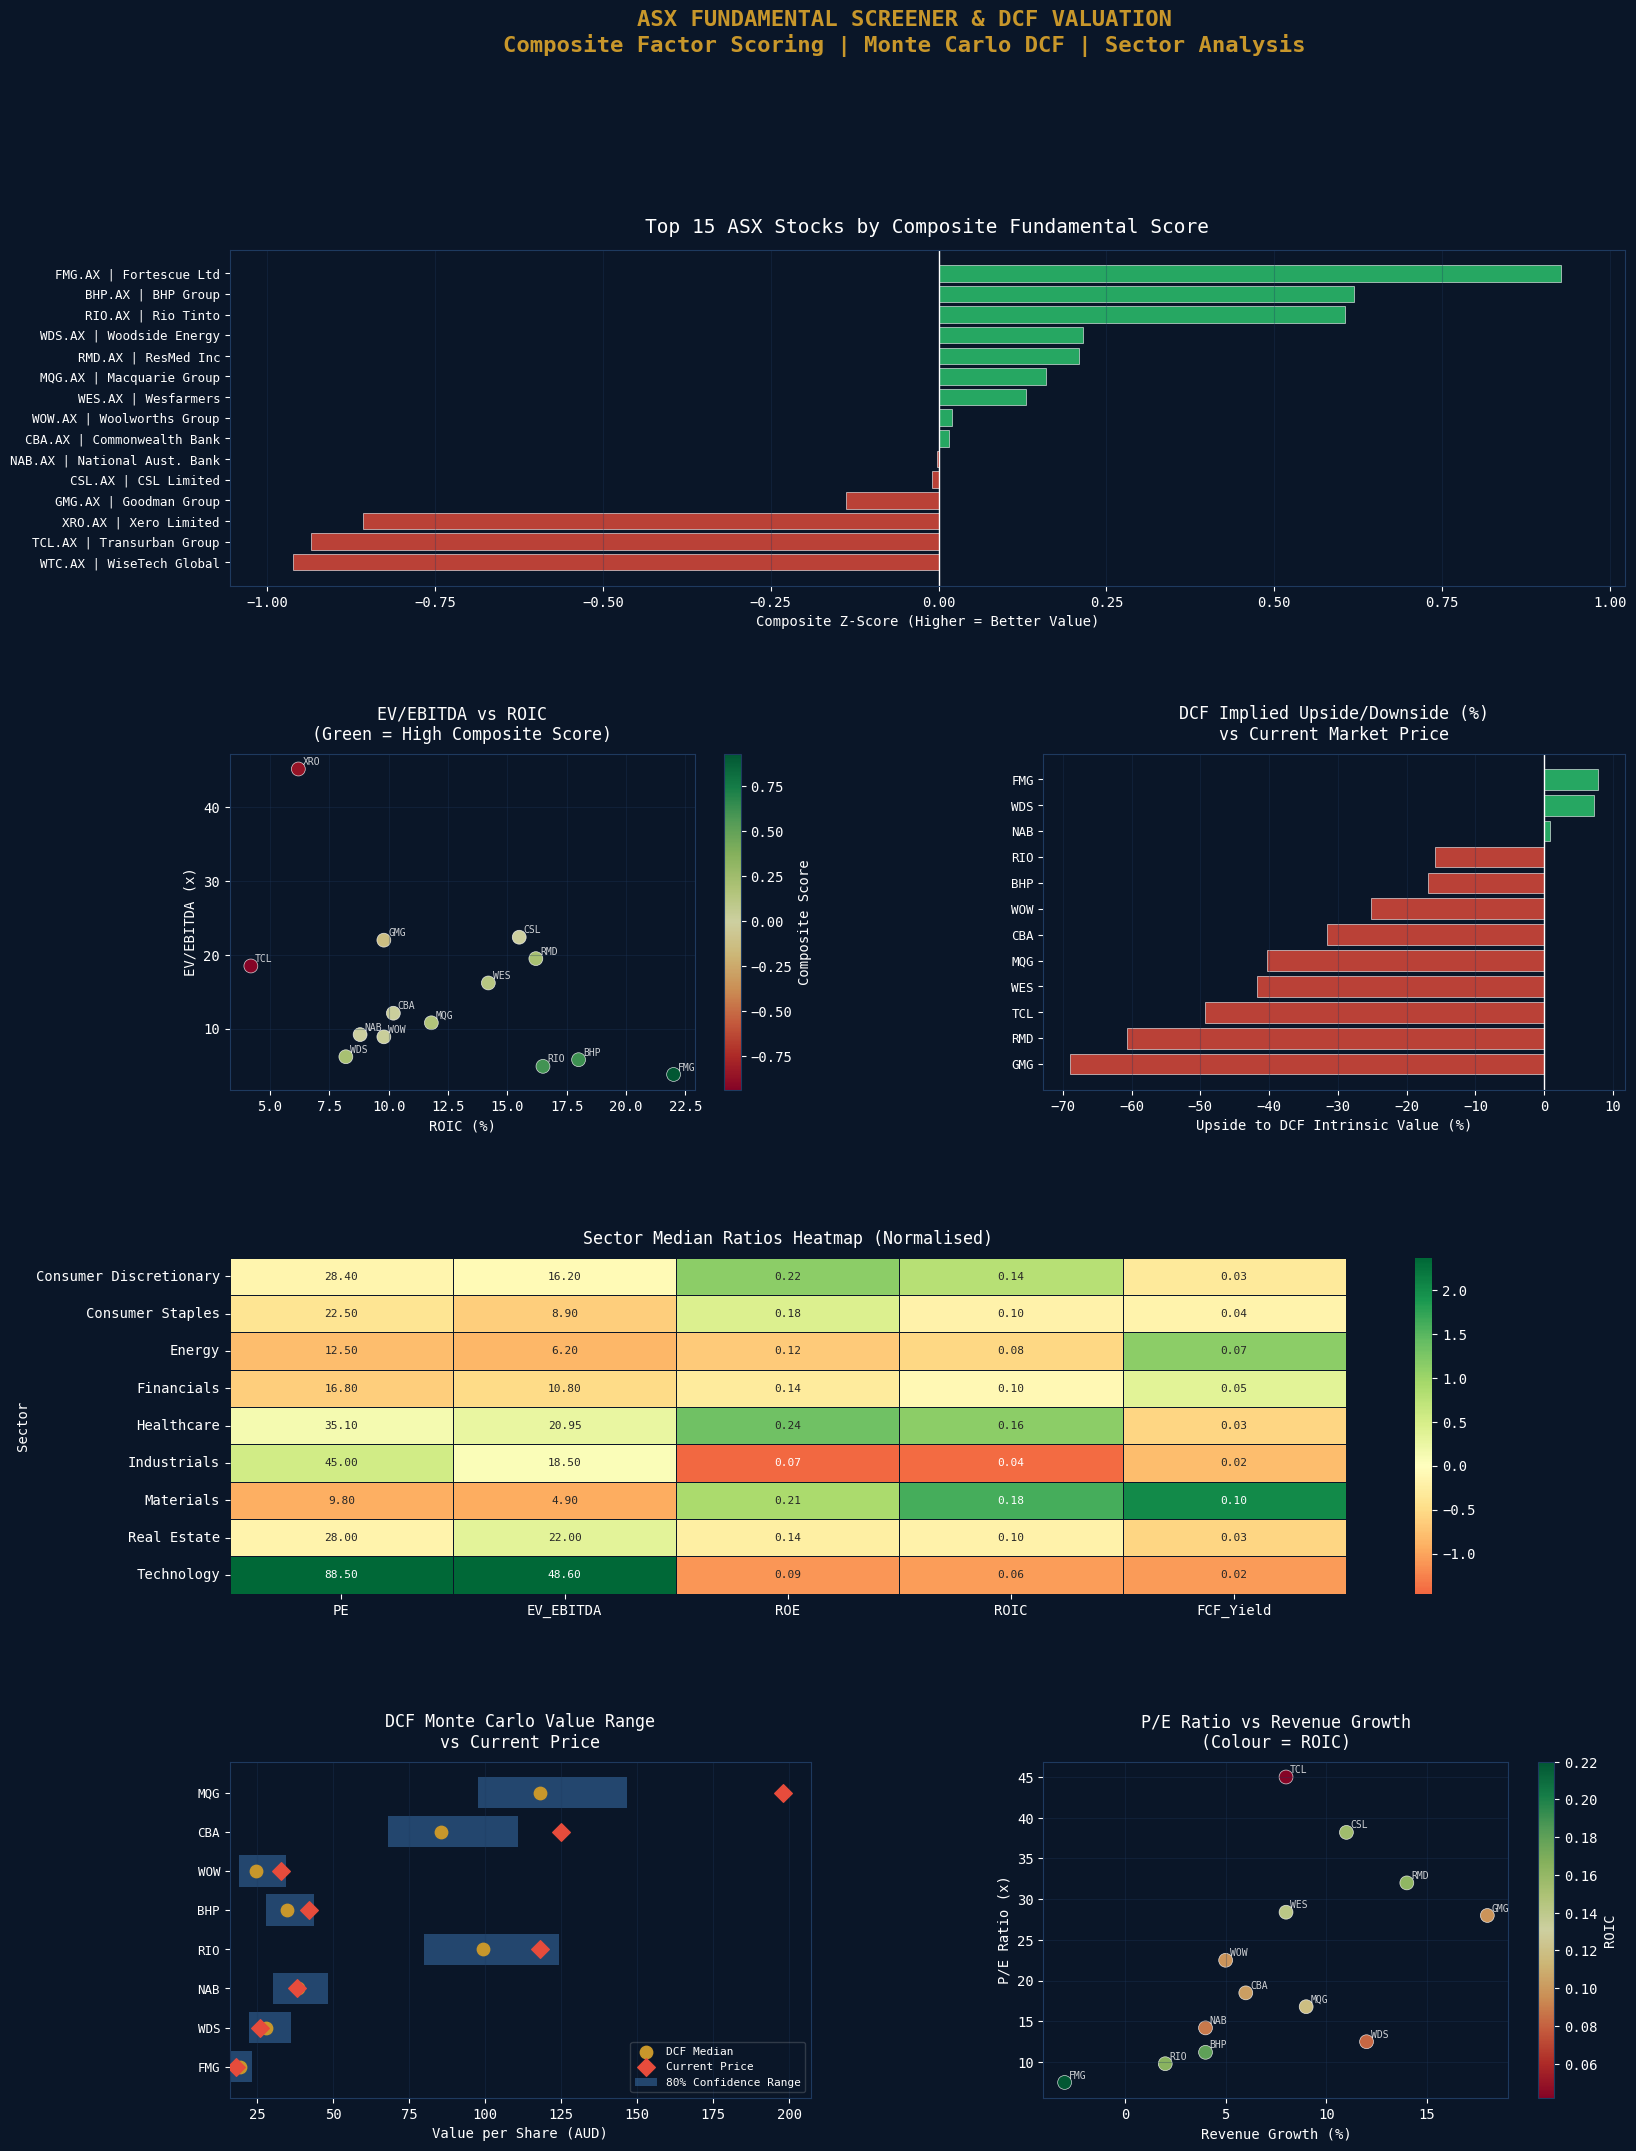

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Chart saved and downloaded!


In [11]:
from google.colab import files

fig = plt.figure(figsize=(18, 24))
fig.patch.set_facecolor('#0A1628')
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.4)

# Chart 1: Composite Score Ranking
ax1 = fig.add_subplot(gs[0, :])
top15       = df_ranked.head(15)
colors_bar  = [GREEN if s > 0 else RED for s in top15['Composite_Score']]
bars = ax1.barh(range(len(top15)), top15['Composite_Score'].values,
                color=colors_bar, alpha=0.8, edgecolor='white', lw=0.5)
ax1.set_yticks(range(len(top15)))
ax1.set_yticklabels([f"{t} | {str(top15.loc[t,'Company'])[:20]}" for t in top15.index],
                    fontsize=9)
ax1.axvline(x=0, color='white', lw=1.0)
ax1.set_title('Top 15 ASX Stocks by Composite Fundamental Score', fontsize=14, color=WHITE, pad=12)
ax1.set_xlabel('Composite Z-Score (Higher = Better Value)', color=WHITE)
ax1.set_facecolor('#0A1628')
ax1.grid(True, alpha=0.3, axis='x')
ax1.invert_yaxis()

# Chart 2: EV/EBITDA vs ROIC Scatter
ax2 = fig.add_subplot(gs[1, 0])
valid = df_score.dropna(subset=['EV_EBITDA', 'ROIC', 'Composite_Score'])
valid = valid[(valid['EV_EBITDA'] > 0) & (valid['EV_EBITDA'] < 50)]
sc = ax2.scatter(valid['ROIC'] * 100,
                 valid['EV_EBITDA'],
                 c=valid['Composite_Score'],
                 cmap='RdYlGn',
                 s=100, alpha=0.8, edgecolors='white', lw=0.5)
for ticker, row in valid.iterrows():
    ax2.annotate(ticker.replace('.AX', ''),
                 (row['ROIC']*100, row['EV_EBITDA']),
                 fontsize=7, color=WHITE, alpha=0.8,
                 xytext=(3, 3), textcoords='offset points')
plt.colorbar(sc, ax=ax2, label='Composite Score')
ax2.set_title('EV/EBITDA vs ROIC\n(Green = High Composite Score)', fontsize=12, color=WHITE, pad=10)
ax2.set_xlabel('ROIC (%)', color=WHITE)
ax2.set_ylabel('EV/EBITDA (x)', color=WHITE)
ax2.set_facecolor('#0A1628')
ax2.grid(True, alpha=0.3)

# Chart 3: DCF Upside Waterfall
ax3 = fig.add_subplot(gs[1, 1])
dcf_plot = dcf_df.head(12)
dcf_colors = [GREEN if u > 0 else RED for u in dcf_plot['upside']]
ax3.barh(range(len(dcf_plot)), dcf_plot['upside'].values,
         color=dcf_colors, alpha=0.8, edgecolor='white', lw=0.5)
ax3.set_yticks(range(len(dcf_plot)))
ax3.set_yticklabels([t.replace('.AX', '') for t in dcf_plot.index], fontsize=9)
ax3.axvline(x=0, color='white', lw=1.0)
ax3.set_title('DCF Implied Upside/Downside (%)\nvs Current Market Price', fontsize=12, color=WHITE, pad=10)
ax3.set_xlabel('Upside to DCF Intrinsic Value (%)', color=WHITE)
ax3.set_facecolor('#0A1628')
ax3.grid(True, alpha=0.3, axis='x')
ax3.invert_yaxis()

# Chart 4: Sector Ratio Heatmap
ax4 = fig.add_subplot(gs[2, :])
sector_metrics = df_score.groupby('Sector')[['PE','EV_EBITDA','ROE','ROIC','FCF_Yield']].median()
sector_metrics = sector_metrics.replace([np.inf, -np.inf], np.nan).dropna(how='all')
sector_norm    = (sector_metrics - sector_metrics.mean()) / sector_metrics.std()
mask = sector_norm.isnull()
sns.heatmap(sector_norm, ax=ax4, cmap='RdYlGn', center=0,
            annot=sector_metrics.round(2), fmt='.2f',
            linewidths=0.5, linecolor='#0A1628',
            mask=mask, annot_kws={'size': 8})
ax4.set_title('Sector Median Ratios Heatmap (Normalised)', fontsize=12, color=WHITE, pad=10)
ax4.set_facecolor('#0A1628')

# Chart 5: DCF Monte Carlo Range
ax5 = fig.add_subplot(gs[3, 0])
dcf_top8 = dcf_df.head(8)
y_pos    = range(len(dcf_top8))
ax5.barh(y_pos,
         dcf_top8['iv_high'] - dcf_top8['iv_low'],
         left=dcf_top8['iv_low'],
         color=BLUE, alpha=0.4, label='80% Confidence Range')
ax5.scatter(dcf_top8['iv_median'], y_pos, color=GOLD, s=80, zorder=5, label='DCF Median')
ax5.scatter(dcf_top8['price'],     y_pos, color=RED,  s=80, marker='D', zorder=5, label='Current Price')
ax5.set_yticks(list(y_pos))
ax5.set_yticklabels([t.replace('.AX', '') for t in dcf_top8.index], fontsize=9)
ax5.set_title('DCF Monte Carlo Value Range\nvs Current Price', fontsize=12, color=WHITE, pad=10)
ax5.set_xlabel('Value per Share (AUD)', color=WHITE)
ax5.legend(fontsize=8, framealpha=0.2)
ax5.set_facecolor('#0A1628')
ax5.grid(True, alpha=0.3, axis='x')

# Chart 6: PE vs Revenue Growth
ax6 = fig.add_subplot(gs[3, 1])
valid2 = df_score.dropna(subset=['PE', 'Rev_Growth'])
valid2 = valid2[(valid2['PE'] > 0) & (valid2['PE'] < 60)]
sc2 = ax6.scatter(valid2['Rev_Growth'] * 100,
                  valid2['PE'],
                  c=valid2['ROIC'],
                  cmap='RdYlGn', s=100, alpha=0.8,
                  edgecolors='white', lw=0.5)
for ticker, row in valid2.iterrows():
    ax6.annotate(ticker.replace('.AX', ''),
                 (row['Rev_Growth']*100, row['PE']),
                 fontsize=7, color=WHITE, alpha=0.8,
                 xytext=(3, 3), textcoords='offset points')
plt.colorbar(sc2, ax=ax6, label='ROIC')
ax6.set_title('P/E Ratio vs Revenue Growth\n(Colour = ROIC)', fontsize=12, color=WHITE, pad=10)
ax6.set_xlabel('Revenue Growth (%)', color=WHITE)
ax6.set_ylabel('P/E Ratio (x)', color=WHITE)
ax6.set_facecolor('#0A1628')
ax6.grid(True, alpha=0.3)

fig.suptitle('ASX FUNDAMENTAL SCREENER & DCF VALUATION\nComposite Factor Scoring | Monte Carlo DCF | Sector Analysis',
             fontsize=16, color=GOLD, y=0.98, fontweight='bold')

plt.savefig('asx_fundamental_screener.png', dpi=150, bbox_inches='tight', facecolor='#0A1628')
plt.show()
files.download('asx_fundamental_screener.png')
print("Chart saved and downloaded!")

In [12]:
print("\n" + "=" * 65)
print("  ASX FUNDAMENTAL SCREENER - SUMMARY REPORT")
print("=" * 65)

print(f"\n  TOP 5 BY COMPOSITE FUNDAMENTAL SCORE:")
print(f"  {'Rank':<5} {'Ticker':<10} {'Company':<28} {'Score':>7} {'PE':>7} {'ROIC':>8}")
print(f"  {'-'*68}")
for i, (ticker, row) in enumerate(df_ranked.head(5).iterrows(), 1):
    roic_pct = row['ROIC']*100 if pd.notna(row['ROIC']) else 0
    print(f"  {i:<5} {ticker:<10} {str(row['Company'])[:26]:<28} {row['Composite_Score']:>6.2f} {row['PE']:>6.1f}x {roic_pct:>6.1f}%")

print(f"\n  TOP 5 BY DCF UPSIDE:")
print(f"  {'Ticker':<10} {'Price':>8} {'DCF Value':>10} {'Upside':>10} {'WACC':>8}")
print(f"  {'-'*50}")
for ticker, row in dcf_df.head(5).iterrows():
    print(f"  {ticker:<10} ${row['price']:>7.2f} ${row['iv_median']:>9.2f} {row['upside']:>+9.1f}% {row['wacc']*100:>7.1f}%")

print(f"\n  UNIVERSE STATISTICS:")
print(f"  Stocks screened      : {len(df)}")
print(f"  DCF valuations run   : {len(dcf_df)}")
print(f"  Median PE ratio      : {df['PE'].median():.1f}x")
print(f"  Median EV/EBITDA     : {df['EV_EBITDA'].median():.1f}x")
print(f"  Median ROIC          : {df['ROIC'].median()*100:.1f}%")

print("\n" + "=" * 65)
print("  PROJECT 3 COMPLETE!")
print("  File saved: asx_fundamental_screener.png")
print("=" * 65)


  ASX FUNDAMENTAL SCREENER - SUMMARY REPORT

  TOP 5 BY COMPOSITE FUNDAMENTAL SCORE:
  Rank  Ticker     Company                        Score      PE     ROIC
  --------------------------------------------------------------------
  1     FMG.AX     Fortescue Ltd                  0.93    7.5x   22.0%
  2     BHP.AX     BHP Group                      0.62   11.2x   18.0%
  3     RIO.AX     Rio Tinto                      0.61    9.8x   16.5%
  4     WDS.AX     Woodside Energy                0.21   12.5x    8.2%
  5     RMD.AX     ResMed Inc                     0.21   32.0x   16.2%

  TOP 5 BY DCF UPSIDE:
  Ticker        Price  DCF Value     Upside     WACC
  --------------------------------------------------
  FMG.AX     $  18.00 $    19.42      +7.9%    12.5%
  WDS.AX     $  26.00 $    27.87      +7.2%    10.1%
  NAB.AX     $  38.00 $    38.31      +0.8%    10.8%
  RIO.AX     $ 118.00 $    99.19     -15.9%    11.2%
  BHP.AX     $  42.00 $    34.90     -16.9%    11.5%

  UNIVERSE STATISTI